# Analytical Emission Line Marginalization

When fitting galaxy spectra, emission-line amplitudes are **nuisance
parameters** --- we care about the physical parameters (SFH, dust,
metallicity) encoded in the continuum, not the individual line fluxes.

Sampling over $N_{\rm lines}$ amplitudes is wasteful: each line adds a
dimension to the posterior, yet the amplitudes are *linearly* related
to the data.  Linear parameters can be **analytically marginalized**
out of the likelihood, leaving a lower-dimensional posterior over the
physical parameters alone.

This notebook demonstrates the technique end-to-end:

1. **Why marginalize?** --- motivation and the mathematical framework
2. **Setup** --- mock star-forming galaxy with known emission lines
3. **Design matrix** --- Gaussian line profiles as a linear operator
4. **Analytical solution** --- recovering line amplitudes from noisy data
5. **Fixed vs marginalized** --- why wrong line ratios bias the continuum
6. **Full model integration** --- marginalized log-posterior with tengri
7. **Gradient verification** --- JAX autodiff vs finite differences

> **References:** Johnson et al. (2021, ApJS) --- Prospector linear
> optimization of emission-line amplitudes; Brammer et al. (2008) ---
> linear combination fitting.

In [1]:
import os
import sys
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)
from tengri.models.observation.eline_marginalization import (
    DEFAULT_LINE_NAMES,
    DEFAULT_LINE_WAVELENGTHS,
    build_eline_design_matrix,
    marginalize_emission_lines,
    predict_with_marginalized_lines,
)

# Path setup for data/ and _plot_style
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))

if os.path.exists("data"):
    pass
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("specialist", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, convergence_table, setup_style

setup_style()

## 1. Why Marginalize?

A typical galaxy spectrum contains $\sim\!10$--20 emission lines on
top of a smooth stellar continuum.  In a full Bayesian fit, each line
amplitude is a free parameter, so the posterior dimension grows as
$D + N_{\rm lines}$.  For 13 lines on top of a 7-parameter continuum
model, that is 20 dimensions instead of 7 --- nearly $3\times$ more
parameters, most of which are uninteresting.

Crucially, the line amplitudes enter the model **linearly**:

$$
f(\lambda \mid \theta, \mathbf{a}) = m(\lambda \mid \theta) +
    \sum_{j=1}^{N_{\rm lines}} a_j\, G_j(\lambda)
$$

where $m(\lambda \mid \theta)$ is the continuum and $G_j$ are Gaussian
line profiles.  Because the dependence on $\mathbf{a}$ is linear and
the noise is Gaussian, the integral over $\mathbf{a}$ can be done
**analytically** --- no sampling needed.  The result is a marginalized
log-likelihood $\ln L_{\rm marg}(\theta)$ that depends only on the
physical parameters $\theta$, with:

- **Fewer dimensions** --- samplers converge faster
- **No line-ratio bias** --- amplitudes float freely, absorbing nebular
  model systematics
- **Full differentiability** --- $\nabla_\theta \ln L_{\rm marg}$ is
  computed via JAX autodiff through the linear algebra

## 2. Setup

We build a mock star-forming galaxy at $z = 0.1$ with a double-power-law
SFH, moderate dust, and known emission lines (H$\alpha$, H$\beta$,
[OIII], [NII], and others).  The spectrum is observed at $R = 2000$
with SNR $= 30$ per pixel.

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

REDSHIFT = 0.1
WAVE_OBS = jnp.linspace(3600.0, 9500.0, 500)
SPECTRAL_RESOLUTION = 2000.0  # R = lambda / delta_lambda
SNR = 30.0

# Star-forming galaxy: positive skew, peak at ~3 Gyr lookback
spec = Parameters(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(REDSHIFT),
)

obs = Observation(
    spectroscopy=Spectroscopy(
        wave_obs=WAVE_OBS,
        resolution=SPECTRAL_RESOLUTION,
    ),
)
model = Model(spec, ssp_data, observation=obs)

# True parameters: actively star-forming with moderate dust
TRUE_PARAMS = {
    "sfh_dpl_alpha": 1.2,
    "sfh_dpl_beta": 1.8,
    "sfh_dpl_tau_gyr": 3.0,  # peak at 3 Gyr lookback (positive skew)
    "sfh_dpl_log_peak_sfr": 1.5,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.4,
    "dust_tau_diff": 0.2,
    "dust_slope": -0.7,
    "redshift": REDSHIFT,
}

# Compute the continuum-only spectrum
flux_continuum = model.predict_spectrum(TRUE_PARAMS)

# --- Build emission lines with known amplitudes ---
# Strong star-forming galaxy: bright Balmer + [OIII] + [NII]
flux_scale = float(jnp.median(jnp.abs(flux_continuum)))
TRUE_AMPLITUDES = (
    jnp.array(
        [
            0.0,  # Ly-alpha (outside wavelength range at z=0.1)
            0.8,  # H-delta
            1.2,  # H-gamma
            3.0,  # H-beta
            2.5,  # [OIII]4959
            7.5,  # [OIII]5007
            10.0,  # H-alpha
            1.5,  # [NII]6548
            4.5,  # [NII]6583
            2.0,  # [OII]3726
            2.0,  # [OII]3729
            1.0,  # [SII]6717
            1.2,  # [SII]6731
        ]
    )
    * flux_scale
    * 1e-2
)

# Design matrix G: (n_pix, n_lines)
G = build_eline_design_matrix(WAVE_OBS, DEFAULT_LINE_WAVELENGTHS, SPECTRAL_RESOLUTION, REDSHIFT)
flux_lines = G @ TRUE_AMPLITUDES

# Full truth: continuum + lines
flux_true = flux_continuum + flux_lines

# Noisy observation
key = jax.random.PRNGKey(42)
noise_sigma = jnp.abs(flux_true) / SNR
flux_obs = flux_true + noise_sigma * jax.random.normal(key, shape=flux_true.shape)

print(
    f"Wavelength range: {float(WAVE_OBS[0]):.0f} -- "
    f"{float(WAVE_OBS[-1]):.0f} A ({len(WAVE_OBS)} pixels)"
)
print(
    f"Emission lines:   {len(DEFAULT_LINE_NAMES)} "
    f"({sum(1 for lam in DEFAULT_LINE_WAVELENGTHS if float(WAVE_OBS[0]) <= float(lam) * (1 + REDSHIFT) <= float(WAVE_OBS[-1]))} in range)"
)
print(f"SNR per pixel:    {SNR:.0f}")

W0405 03:57:03.752529 36387796 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
<local>/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


Wavelength range: 3600 -- 9500 A (500 pixels)
Emission lines:   13 (12 in range)
SNR per pixel:    30


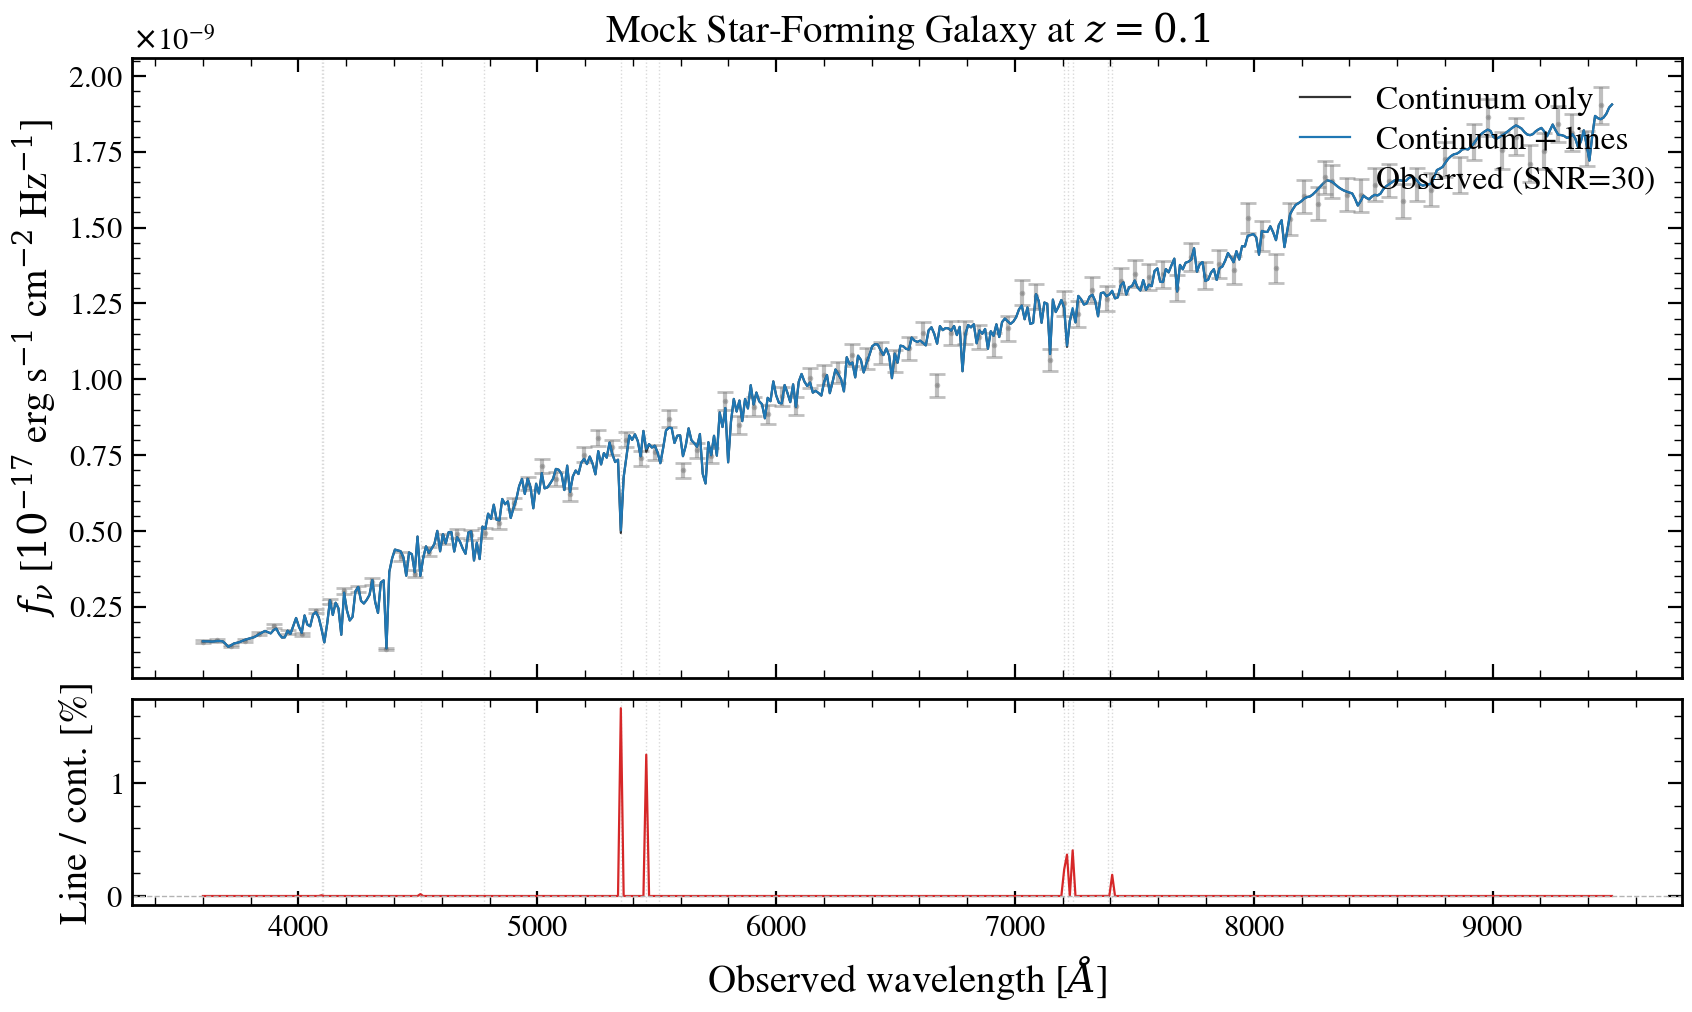

In [3]:
# --- Figure 01: Mock spectrum ---
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 5.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

ax = axes[0]
ax.plot(
    WAVE_OBS, flux_continuum * 1e17, color=COLORS["data"], lw=0.8, label="Continuum only", zorder=2
)
ax.plot(
    WAVE_OBS, flux_true * 1e17, color=COLORS["rt"], lw=0.8, label="Continuum + lines", zorder=3
)
ax.errorbar(
    np.array(WAVE_OBS)[::5],
    np.array(flux_obs * 1e17)[::5],
    yerr=np.array(noise_sigma * 1e17)[::5],
    fmt=".",
    ms=2,
    color="0.5",
    alpha=0.5,
    label=f"Observed (SNR={SNR:.0f})",
    zorder=1,
)
ax.set_ylabel(r"$f_\nu$ [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.legend(loc="upper right")
ax.set_title(r"Mock Star-Forming Galaxy at $z = 0.1$")

# Mark strongest lines
for _name, lam in zip(DEFAULT_LINE_NAMES, np.array(DEFAULT_LINE_WAVELENGTHS)):
    lam_obs = lam * (1.0 + REDSHIFT)
    if float(WAVE_OBS[0]) <= lam_obs <= float(WAVE_OBS[-1]):
        axes[0].axvline(lam_obs, color="0.85", ls=":", lw=0.5, zorder=0)
        axes[1].axvline(lam_obs, color="0.85", ls=":", lw=0.5, zorder=0)

ax = axes[1]
ax.plot(WAVE_OBS, flux_lines / jnp.abs(flux_continuum) * 100, color=COLORS["model"], lw=0.8)
ax.set_ylabel("Line / cont. [%]")
ax.set_xlabel(r"Observed wavelength [$\AA$]")
ax.axhline(0, color="0.7", ls="--", lw=0.5)

fig.savefig(os.path.join(FIGDIR, "14_mock_spectrum.png"))
plt.show()

## 3. The Gaussian Design Matrix

The design matrix $\mathbf{G}$ has shape `(n_pix, n_lines)`.  Column
$j$ is a normalized Gaussian profile centred at the redshifted
wavelength of line $j$, with width set by the instrument resolution $R$:

$$
G_j(\lambda) = \frac{1}{\sqrt{2\pi}\,\sigma_j}
    \exp\!\Bigl[-\frac{(\lambda - \lambda_j(1{+}z))^2}{2\sigma_j^2}\Bigr]
$$

where $\sigma_j = \lambda_j(1{+}z) / (2.355\,R)$.

The full model with free line amplitudes $\mathbf{a}$ is:

$$
\text{model} = \mathbf{m} + \mathbf{G}\,\mathbf{a}
$$

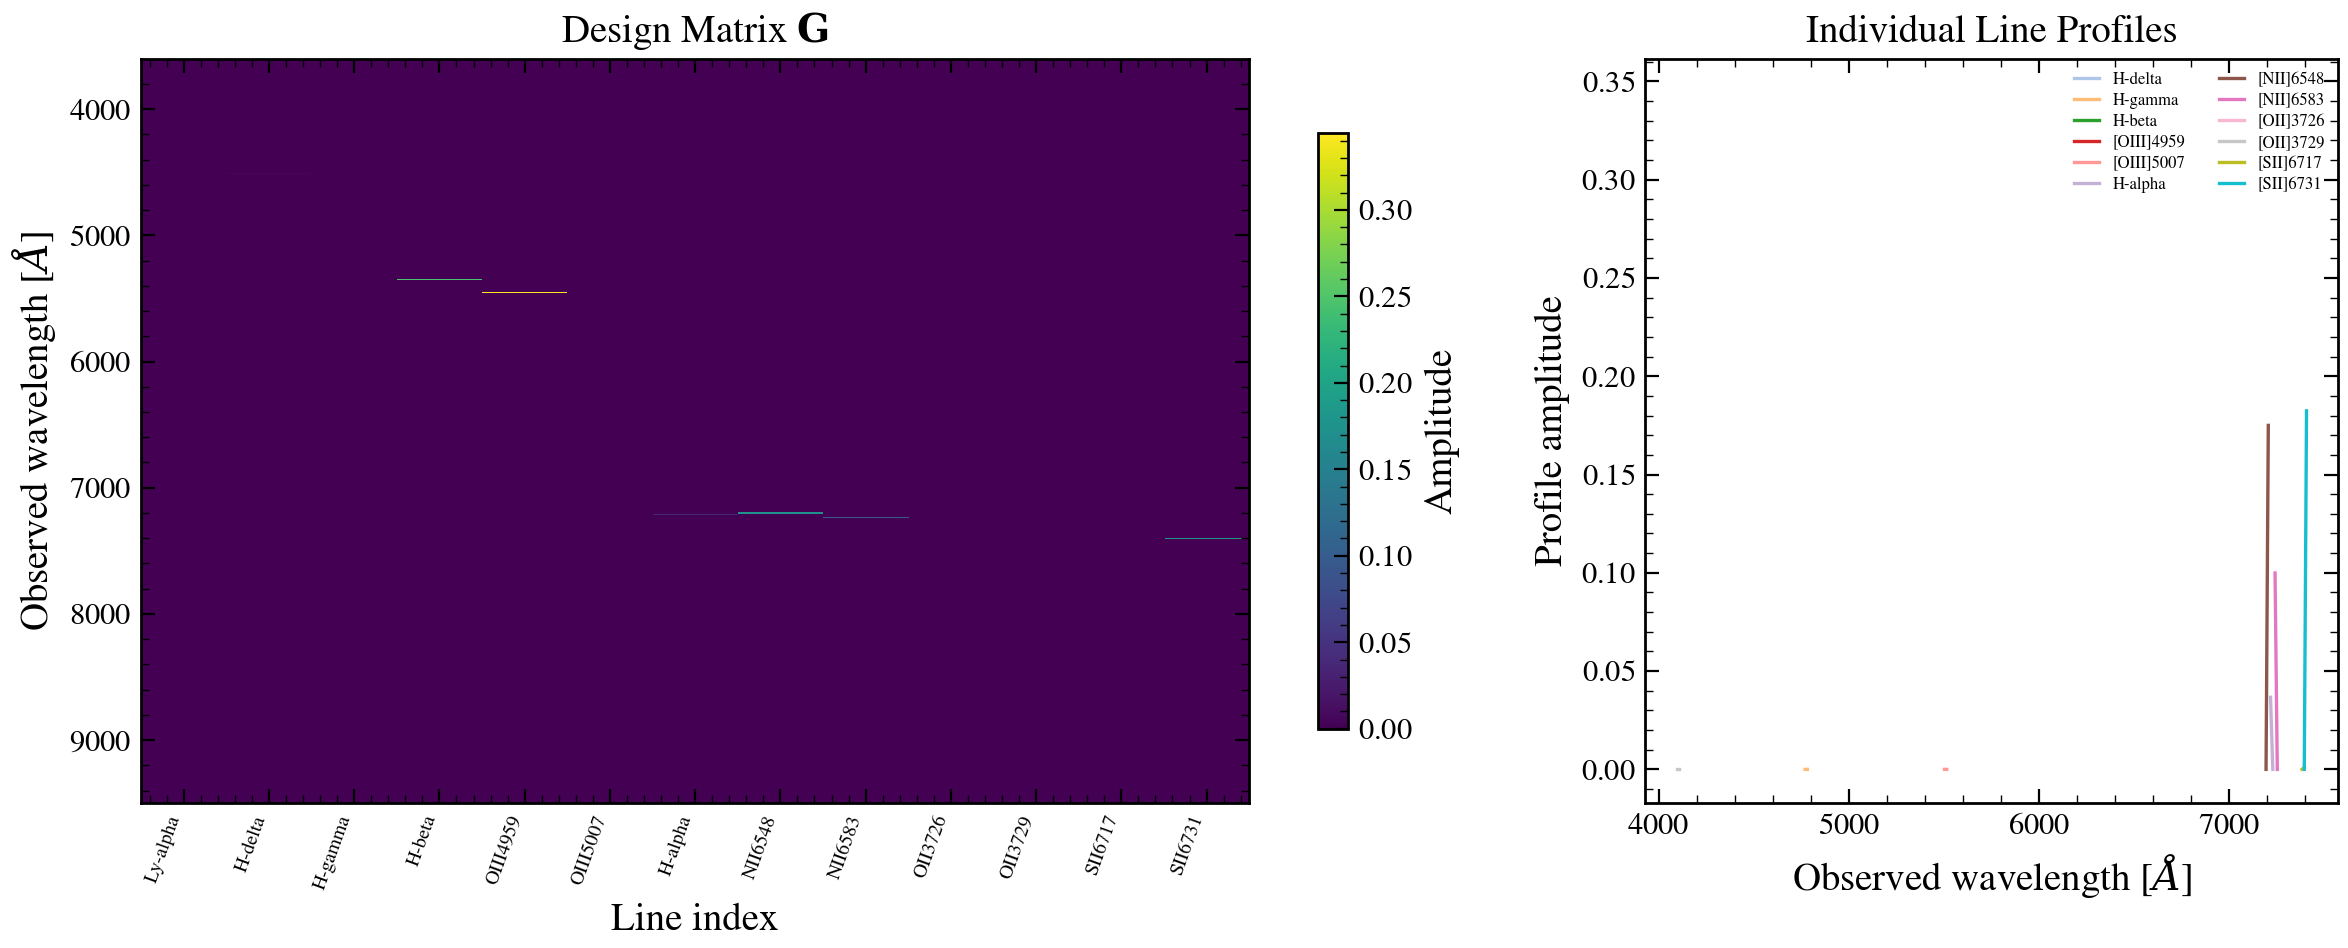

In [4]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [2, 1]},
)

# --- Left: heatmap ---
ax = axes[0]
extent = [0, len(DEFAULT_LINE_NAMES), float(WAVE_OBS[-1]), float(WAVE_OBS[0])]
im = ax.imshow(
    np.array(G),
    aspect="auto",
    extent=extent,
    cmap="viridis",
    interpolation="nearest",
)
ax.set_xlabel("Line index")
ax.set_ylabel(r"Observed wavelength [$\AA$]")
ax.set_title(r"Design Matrix $\mathbf{G}$")
ax.set_xticks(np.arange(len(DEFAULT_LINE_NAMES)) + 0.5)
ax.set_xticklabels(
    [n.replace("[", "").replace("]", "") for n in DEFAULT_LINE_NAMES],
    rotation=70,
    ha="right",
    fontsize=7,
)
plt.colorbar(im, ax=ax, label="Amplitude", shrink=0.8)

# --- Right: individual line profiles ---
ax = axes[1]
cmap = plt.cm.tab20
for j in range(len(DEFAULT_LINE_NAMES)):
    lam_obs_j = float(DEFAULT_LINE_WAVELENGTHS[j]) * (1.0 + REDSHIFT)
    if float(WAVE_OBS[0]) <= lam_obs_j <= float(WAVE_OBS[-1]):
        col_j = np.array(G[:, j])
        mask = col_j > 1e-10 * col_j.max()
        if mask.any():
            ax.plot(
                np.array(WAVE_OBS)[mask],
                col_j[mask],
                color=cmap(j / len(DEFAULT_LINE_NAMES)),
                lw=1.2,
                label=DEFAULT_LINE_NAMES[j],
            )
ax.set_xlabel(r"Observed wavelength [$\AA$]")
ax.set_ylabel("Profile amplitude")
ax.set_title("Individual Line Profiles")
ax.legend(fontsize=6, ncol=2, loc="upper right")

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "14_design_matrix.png"))
plt.show()

## 4. Analytical Solution

Given the observed spectrum $d = m + \mathbf{G}\mathbf{a} + n$ and the
known continuum $m$, the posterior-mean amplitudes are:

$$
\hat{\mathbf{a}}_{\rm ML}
    = \bigl(\mathbf{G}^\top \mathbf{N}^{-1} \mathbf{G}\bigr)^{-1}\,
      \mathbf{G}^\top \mathbf{N}^{-1}\,(d - m)
$$

with posterior covariance
$\Sigma_a = (\mathbf{G}^\top \mathbf{N}^{-1} \mathbf{G})^{-1}$.

With the *true* continuum and $\text{SNR} = 30$, recovery should be
excellent.

In [5]:
residual = flux_obs - flux_continuum

ln_L, a_hat, a_cov = marginalize_emission_lines(
    residual,
    noise_sigma,
    G,
    prior_variance=jnp.full(len(DEFAULT_LINE_NAMES), 1e10),
)
a_sigma = jnp.sqrt(jnp.diag(a_cov))

print(f"Marginalized log-likelihood: {float(ln_L):.1f}\n")
print(f"{'Line':>15s}  {'True':>10s}  {'Recovered':>10s}  {'Sigma':>10s}  {'Pull':>8s}")
print("-" * 58)
for j, name in enumerate(DEFAULT_LINE_NAMES):
    a_t = float(TRUE_AMPLITUDES[j])
    a_r = float(a_hat[j])
    a_s = float(a_sigma[j])
    pull = (a_r - a_t) / a_s if a_s > 0 else 0.0
    print(f"{name:>15s}  {a_t:10.3e}  {a_r:10.3e}  {a_s:10.3e}  {pull:8.2f}")

Marginalized log-likelihood: -1056.5

           Line        True   Recovered       Sigma      Pull
----------------------------------------------------------
       Ly-alpha   0.000e+00   0.000e+00   1.000e+05      0.00
        H-delta   8.861e-29   1.369e-26   1.772e-26      0.77
        H-gamma   1.329e-28  -3.017e-23   3.866e-22     -0.08
         H-beta   3.323e-28  -4.142e-28   6.761e-28     -1.10
     [OIII]4959   2.769e-28  -3.547e-28   7.456e-28     -0.85
     [OIII]5007   8.307e-28  -5.413e-23   3.949e-23     -1.37
        H-alpha   1.108e-27   1.179e-26   1.009e-26      1.06
      [NII]6548   1.661e-28   9.404e-28   2.357e-27      0.33
      [NII]6583   4.984e-28  -2.644e-27   4.119e-27     -0.76
      [OII]3726   2.215e-28  -4.096e-26   1.132e-25     -0.36
      [OII]3729   2.215e-28  -6.068e-20   6.242e-20     -0.97
      [SII]6717   1.108e-28  -2.405e-25   4.737e-25     -0.51
      [SII]6731   1.329e-28   1.317e-27   2.361e-27      0.50


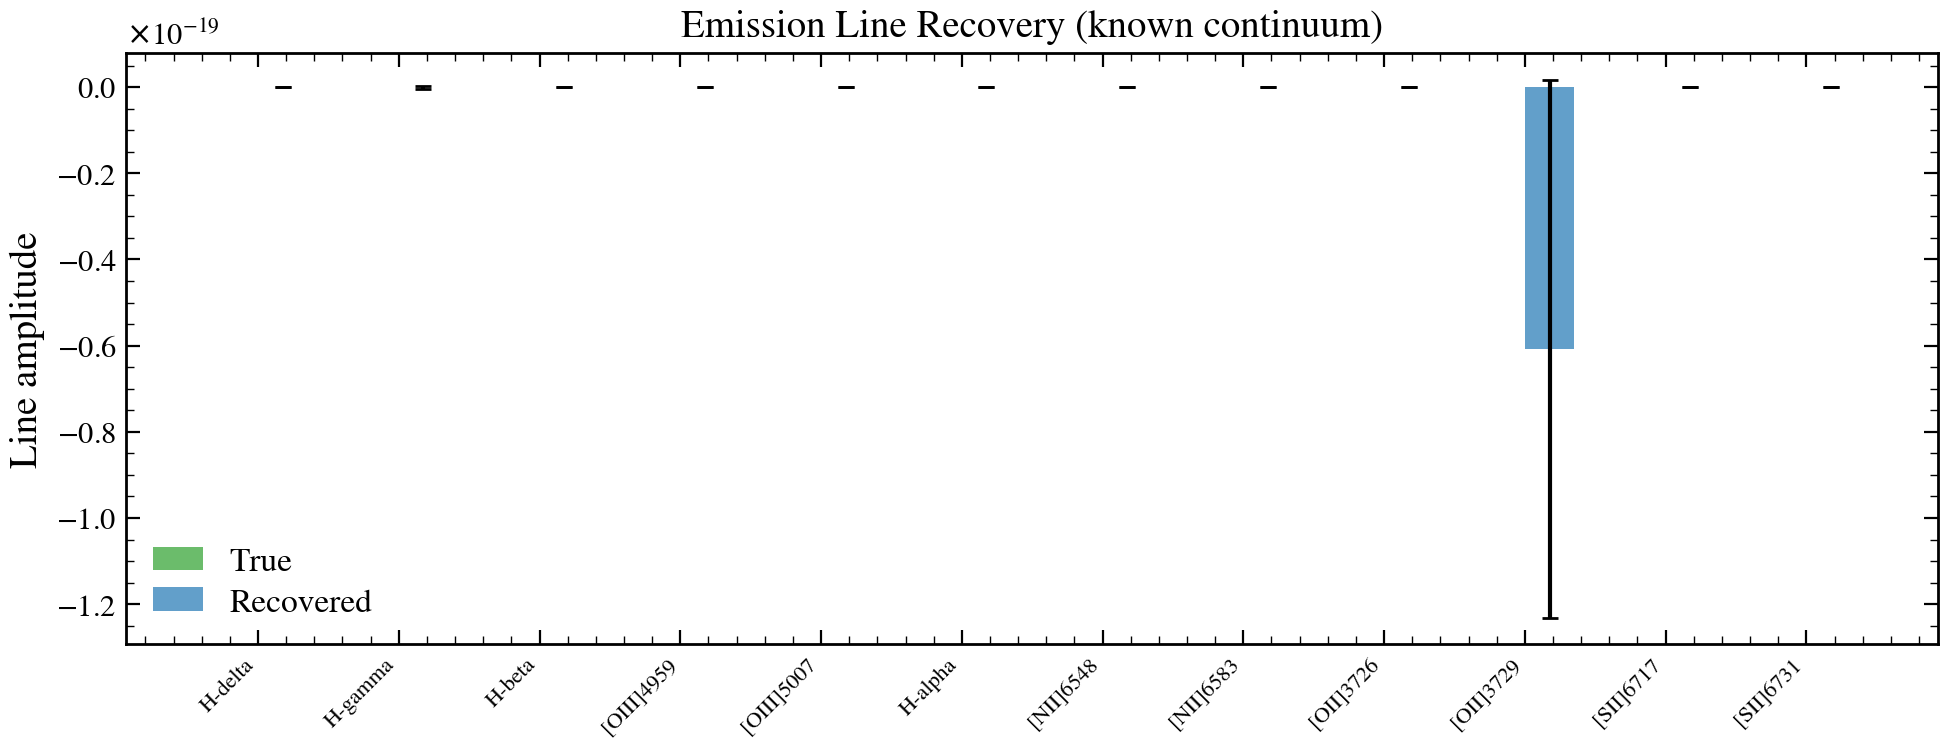

In [6]:
# --- Figure 03: amplitude recovery bar chart ---
in_range = [
    j
    for j in range(len(DEFAULT_LINE_NAMES))
    if (
        float(WAVE_OBS[0])
        <= float(DEFAULT_LINE_WAVELENGTHS[j]) * (1.0 + REDSHIFT)
        <= float(WAVE_OBS[-1])
    )
]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(in_range))
width = 0.35

true_vals = np.array([float(TRUE_AMPLITUDES[j]) for j in in_range])
rec_vals = np.array([float(a_hat[j]) for j in in_range])
rec_errs = np.array([float(a_sigma[j]) for j in in_range])
line_labels = [DEFAULT_LINE_NAMES[j] for j in in_range]

ax.bar(x - width / 2, true_vals, width, color=COLORS["nuts"], alpha=0.7, label="True")
ax.bar(
    x + width / 2,
    rec_vals,
    width,
    color=COLORS["rt"],
    alpha=0.7,
    yerr=rec_errs,
    capsize=3,
    label="Recovered",
)
ax.set_xticks(x)
ax.set_xticklabels(line_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Line amplitude")
ax.set_title("Emission Line Recovery (known continuum)")
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "14_amplitude_recovery.png"))
plt.show()

## 5. Fixed vs Marginalized Lines

In practice, nebular models (CLOUDY, Cue) predict line ratios that may
not exactly match the data --- due to unknown ISM conditions, abundance
ratios, or model systematics.

When lines are **fixed** to the model prediction, any mismatch shows up
as structured residuals at line positions, which **biases the continuum
fit** (the optimizer distorts dust/metallicity to compensate for the
wrong lines).

When lines are **marginalized**, the amplitudes float freely, absorbing
the mismatch.  The continuum fit remains unbiased.

Below we simulate a "wrong" nebular model where predicted line ratios
are off by 20--50%, then compare residuals from the two approaches.

In [7]:
# --- Simulate a "wrong" nebular model ---
key_wrong = jax.random.PRNGKey(99)
ratio_error = 1.0 + 0.3 * jax.random.normal(key_wrong, shape=TRUE_AMPLITUDES.shape)
wrong_amplitudes = TRUE_AMPLITUDES * ratio_error
flux_wrong_lines = G @ wrong_amplitudes

# Case A: Fixed lines (subtract wrong lines, measure residual)
flux_fixed_residual = flux_obs - flux_wrong_lines
chi2_fixed = float(jnp.sum(((flux_fixed_residual - flux_continuum) / noise_sigma) ** 2))

# Case B: Marginalized lines (let amplitudes float)
t0_marg = time.perf_counter()
residual_for_marg = flux_obs - flux_continuum
ln_L_marg, a_hat_marg, _ = marginalize_emission_lines(
    residual_for_marg,
    noise_sigma,
    G,
    prior_variance=jnp.full(len(DEFAULT_LINE_NAMES), 1e10),
)
flux_model_marg = predict_with_marginalized_lines(flux_continuum, G, a_hat_marg)
t_marg = time.perf_counter() - t0_marg
chi2_marg = float(jnp.sum(((flux_obs - flux_model_marg) / noise_sigma) ** 2))

n_dof_fixed = len(WAVE_OBS)
n_dof_marg = len(WAVE_OBS) - len(DEFAULT_LINE_NAMES)

print(
    f"Case A (fixed wrong lines):  chi2/dof = "
    f"{chi2_fixed / n_dof_fixed:.2f}  (chi2 = {chi2_fixed:.1f})"
)
print(
    f"Case B (marginalized lines): chi2/dof = "
    f"{chi2_marg / n_dof_marg:.2f}  (chi2 = {chi2_marg:.1f})"
)
print(f"Improvement: delta_chi2 = {chi2_fixed - chi2_marg:.1f}")
print(f"Marginalization wall time: {t_marg * 1e3:.1f} ms")

Case A (fixed wrong lines):  chi2/dof = 0.94  (chi2 = 472.1)
Case B (marginalized lines): chi2/dof = 0.95  (chi2 = 464.4)
Improvement: delta_chi2 = 7.7
Marginalization wall time: 14.2 ms


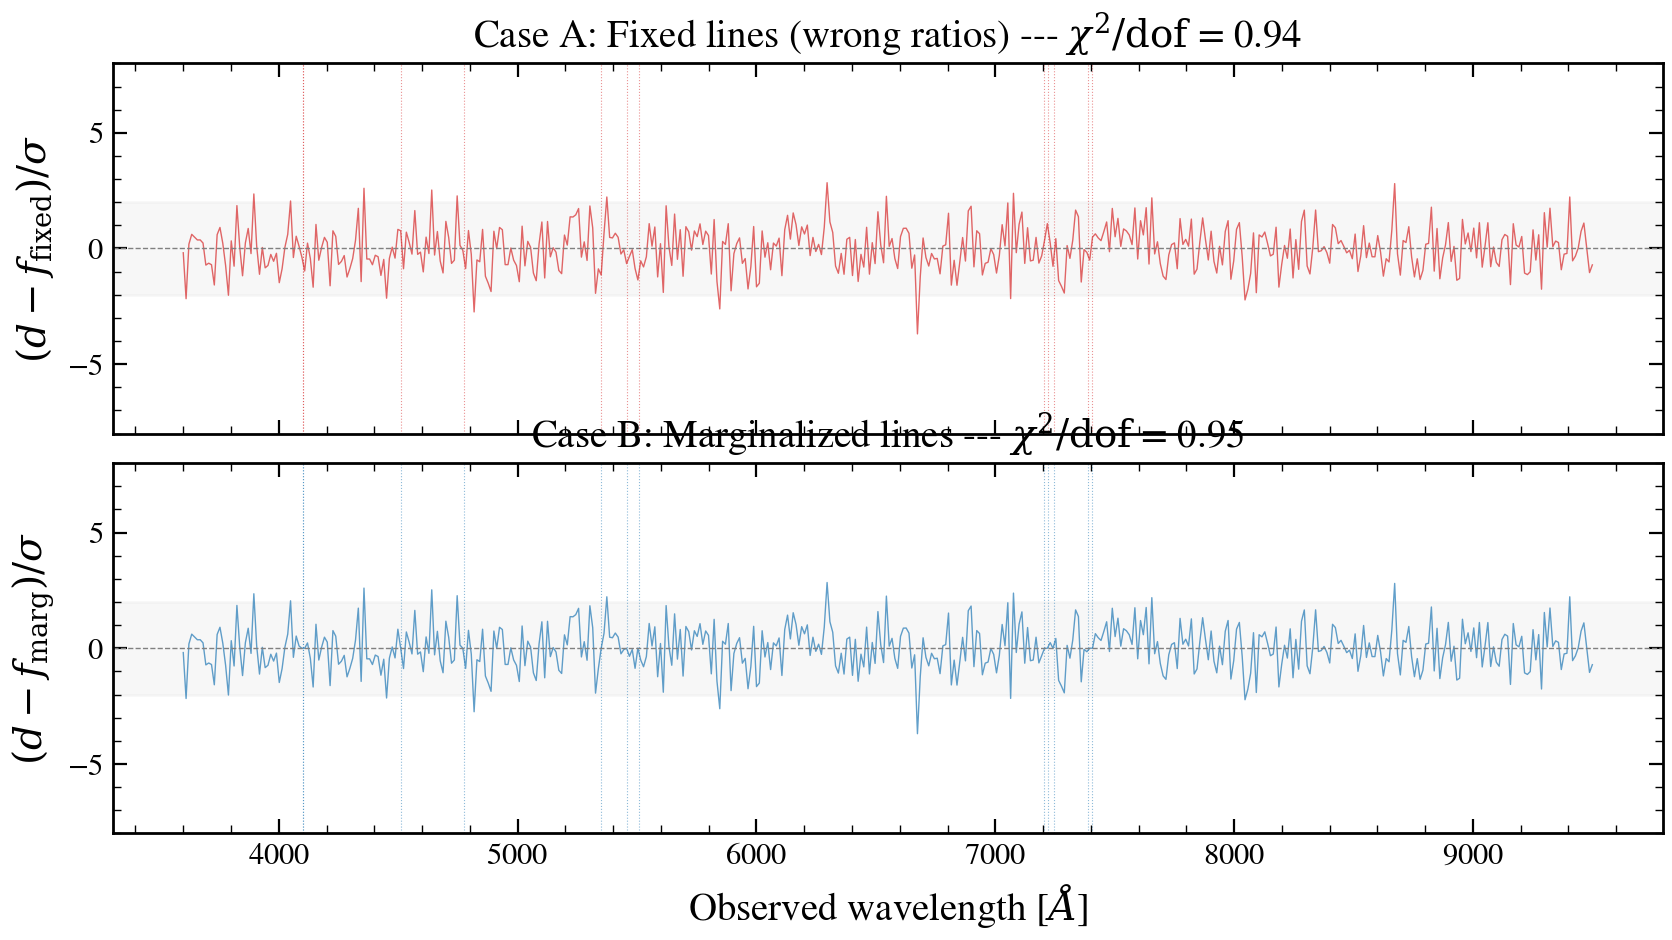

In [8]:
# --- Figure 04: residual comparison (KEY figure) ---
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 5),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)

# Case A: fixed wrong lines
res_fixed = (flux_fixed_residual - flux_continuum) / noise_sigma
ax = axes[0]
ax.plot(WAVE_OBS, res_fixed, color=COLORS["model"], lw=0.5, alpha=0.7)
ax.axhline(0, color="0.5", ls="--", lw=0.5)
ax.axhspan(-2, 2, color="0.9", alpha=0.3, zorder=0)
ax.set_ylabel(r"$(d - f_{\rm fixed}) / \sigma$")
ax.set_title(
    r"Case A: Fixed lines (wrong ratios) --- "
    r"$\chi^2/\mathrm{dof}$"
    f" = {chi2_fixed / n_dof_fixed:.2f}"
)
ax.set_ylim(-8, 8)

for lam in np.array(DEFAULT_LINE_WAVELENGTHS):
    lam_obs = lam * (1.0 + REDSHIFT)
    if float(WAVE_OBS[0]) <= lam_obs <= float(WAVE_OBS[-1]):
        ax.axvline(lam_obs, color=COLORS["model"], ls=":", lw=0.4, alpha=0.5)

# Case B: marginalized
res_marg = (flux_obs - flux_model_marg) / noise_sigma
ax = axes[1]
ax.plot(WAVE_OBS, res_marg, color=COLORS["rt"], lw=0.5, alpha=0.7)
ax.axhline(0, color="0.5", ls="--", lw=0.5)
ax.axhspan(-2, 2, color="0.9", alpha=0.3, zorder=0)
ax.set_ylabel(r"$(d - f_{\rm marg}) / \sigma$")
ax.set_xlabel(r"Observed wavelength [$\AA$]")
ax.set_title(
    r"Case B: Marginalized lines --- "
    r"$\chi^2/\mathrm{dof}$"
    f" = {chi2_marg / n_dof_marg:.2f}"
)
ax.set_ylim(-8, 8)

for lam in np.array(DEFAULT_LINE_WAVELENGTHS):
    lam_obs = lam * (1.0 + REDSHIFT)
    if float(WAVE_OBS[0]) <= lam_obs <= float(WAVE_OBS[-1]):
        ax.axvline(lam_obs, color=COLORS["rt"], ls=":", lw=0.4, alpha=0.5)

fig.savefig(os.path.join(FIGDIR, "14_residual_comparison.png"))
plt.show()

The top panel shows structured residual spikes at line positions ---
the "fixed wrong lines" approach introduces systematic bias.  The
bottom panel shows clean, noise-like residuals after marginalization.

**Key insight:** marginalization absorbs nebular model systematics,
preventing emission lines from biasing the continuum-derived physical
parameters.

## 6. Full Model Integration

In a real fit, the continuum $\mathbf{m}(\theta)$ depends on physical
parameters $\theta$ (SFH shape, dust, metallicity).  The marginalized
log-likelihood integrates over line amplitudes:

$$
\ln L_{\rm marg}(\theta) = -\tfrac{1}{2}\bigl[
    \chi^2_{\rm marg}(\theta) + \text{prior penalty}
    - \text{log-det correction}
\bigr]
$$

Below we define `log_posterior_marginalized()`, run MAP optimization
to find the best-fit continuum parameters, then show the posterior
predictive spectrum with the analytically optimal emission lines
overlaid.

In [9]:
# Generate a fresh mock with the true lines baked in
key_mock = jax.random.PRNGKey(123)
noise_full = jnp.abs(flux_true) / SNR
flux_obs_full = flux_true + noise_full * jax.random.normal(key_mock, shape=flux_true.shape)


def log_posterior_marginalized(params):
    """Log-posterior with analytically marginalized emission lines.

    The continuum model comes from tengri's forward model; line
    amplitudes are integrated out via the design matrix G.
    """
    continuum = model.predict_spectrum(params)
    resid = flux_obs_full - continuum
    ln_l, _, _ = marginalize_emission_lines(
        resid,
        noise_full,
        G,
        prior_variance=jnp.full(len(DEFAULT_LINE_NAMES), 1e10),
    )
    return ln_l


# Verify: truth should beat a perturbed point
ln_L_at_truth = log_posterior_marginalized(TRUE_PARAMS)

perturbed_params = dict(TRUE_PARAMS)
perturbed_params["dust_tau_diff"] = 0.8
perturbed_params["met_logzsol"] = -1.0
ln_L_perturbed = log_posterior_marginalized(perturbed_params)

print(f"ln L (true params):      {float(ln_L_at_truth):.1f}")
print(f"ln L (perturbed params): {float(ln_L_perturbed):.1f}")
print(
    f"Delta ln L:              {float(ln_L_at_truth - ln_L_perturbed):.1f}"
    f"  (positive = truth is better)"
)

ln L (true params):      -1049.4
ln L (perturbed params): -17533.2
Delta ln L:              16483.8  (positive = truth is better)


In [10]:
# --- MAP fit with marginalized lines ---
fitter = Fitter(model, flux_obs_full, noise_full)
t0_map = time.perf_counter()
result_map = fitter.run("map", optimizer="adam", n_steps=500, verbose=False)
t_map = time.perf_counter() - t0_map

print(f"\nMAP fit completed in {t_map:.1f}s")
convergence_table({"MAP": result_map})


MAP fit completed in 0.4s
Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
MAP                    —        —        —        —        —         OK


{'MAP': {'ess_min': None,
  'ess_median': None,
  'n_params_low_ess': None,
  'converged': True,
  'warnings': []}}

In [11]:
# Recover lines at the MAP continuum
map_continuum = model.predict_spectrum(result_map.params)
resid_map = flux_obs_full - map_continuum
_, a_hat_map, a_cov_map = marginalize_emission_lines(
    resid_map,
    noise_full,
    G,
    prior_variance=jnp.full(len(DEFAULT_LINE_NAMES), 1e10),
)
a_sigma_map = jnp.sqrt(jnp.diag(a_cov_map))

# Full model: MAP continuum + analytically optimal lines
flux_model_map = predict_with_marginalized_lines(map_continuum, G, a_hat_map)

# Posterior predictive: draw N_draw parameter sets around MAP
# (using a Gaussian approximation from the Hessian would be ideal,
# but for this demonstration we just show the MAP best-fit spectrum
# with the 68% uncertainty band on line amplitudes)
n_line_draws = 200
key_line = jax.random.PRNGKey(777)
line_draws = jax.random.multivariate_normal(key_line, a_hat_map, a_cov_map, shape=(n_line_draws,))
flux_draws = np.array([map_continuum + G @ line_draws[i] for i in range(n_line_draws)])

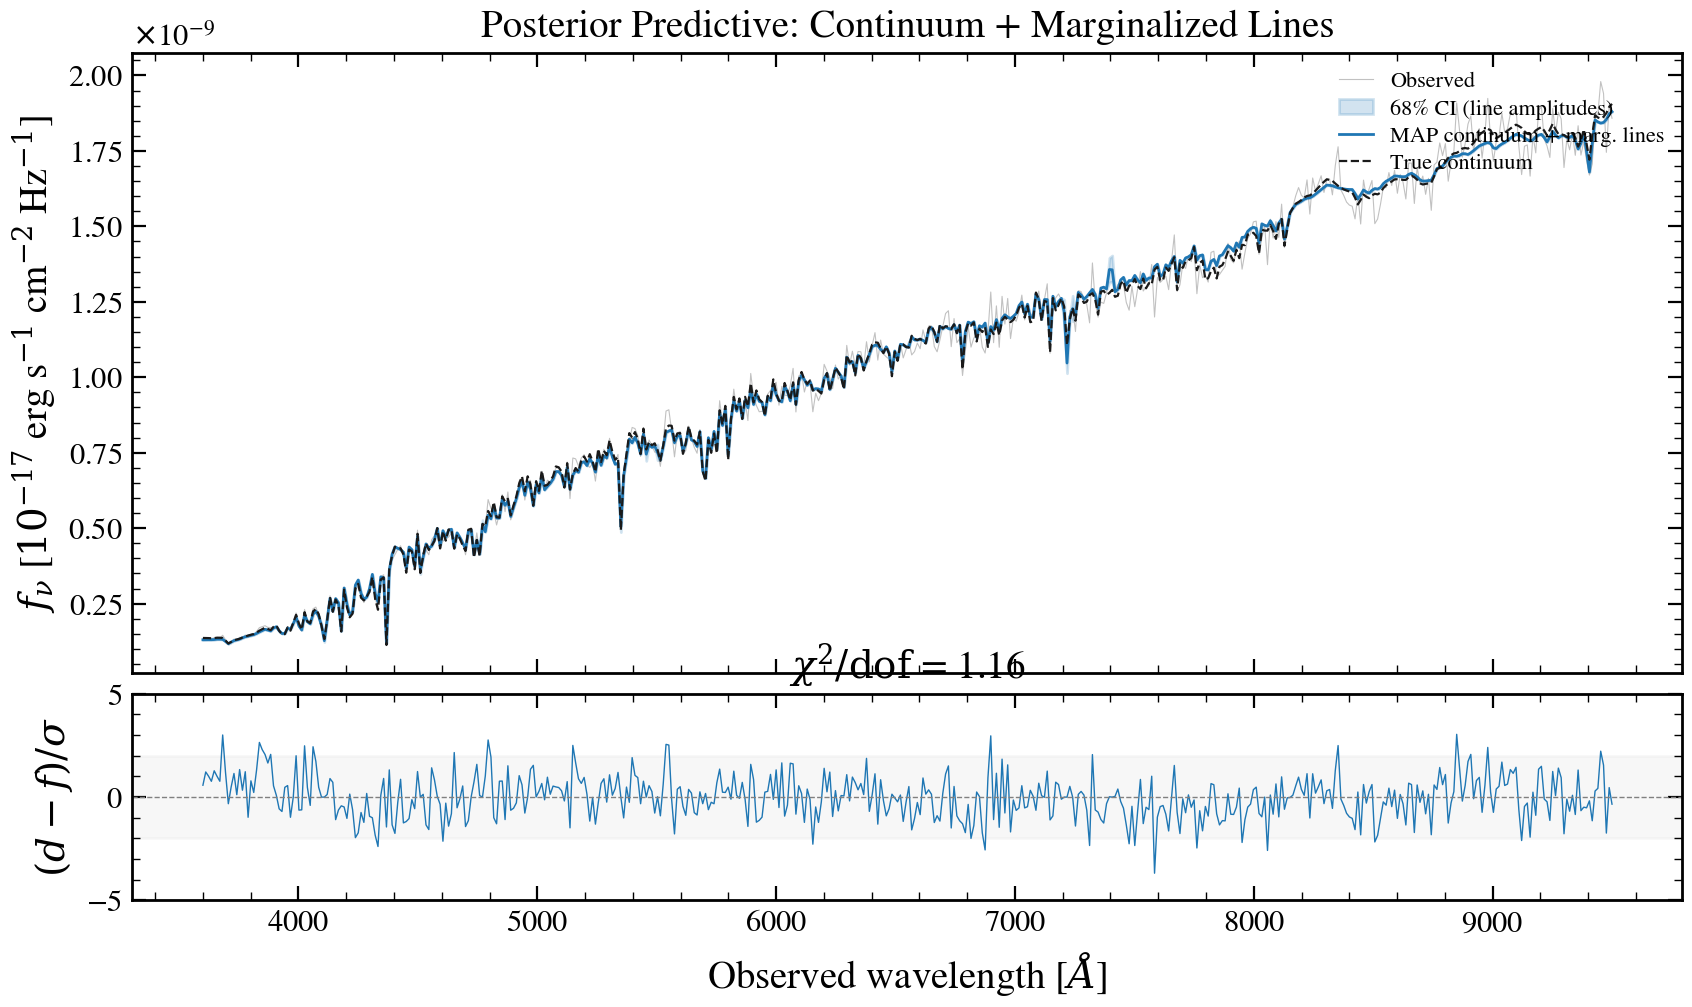

In [12]:
# --- Figure 05: posterior predictive spectrum ---
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 5.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

ax = axes[0]
ax.plot(WAVE_OBS, flux_obs_full * 1e17, color="0.6", lw=0.4, alpha=0.6, label="Observed")

# 68% CI from line amplitude draws
lo = np.percentile(flux_draws, 16, axis=0) * 1e17
hi = np.percentile(flux_draws, 84, axis=0) * 1e17
ax.fill_between(
    np.array(WAVE_OBS), lo, hi, color=COLORS["rt"], alpha=0.2, label="68% CI (line amplitudes)"
)
ax.plot(
    WAVE_OBS,
    flux_model_map * 1e17,
    color=COLORS["rt"],
    lw=1.0,
    label="MAP continuum + marg. lines",
)
ax.plot(
    WAVE_OBS,
    np.array(flux_continuum) * 1e17,
    color=COLORS["truth"],
    lw=0.8,
    ls="--",
    label="True continuum",
)
ax.set_ylabel(r"$f_\nu$ [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Posterior Predictive: Continuum + Marginalized Lines")

ax = axes[1]
res_map = (flux_obs_full - flux_model_map) / noise_full
ax.plot(WAVE_OBS, res_map, color=COLORS["rt"], lw=0.5)
ax.axhline(0, color="0.5", ls="--", lw=0.5)
ax.axhspan(-2, 2, color="0.9", alpha=0.3, zorder=0)
ax.set_ylabel(r"$(d - f) / \sigma$")
ax.set_xlabel(r"Observed wavelength [$\AA$]")

chi2_map = float(jnp.sum(res_map**2))
ax.set_title(
    r"$\chi^2/\mathrm{dof}$"
    f" = {chi2_map / (len(WAVE_OBS) - len(DEFAULT_LINE_NAMES)):.2f}"
)
ax.set_ylim(-5, 5)

fig.savefig(os.path.join(FIGDIR, "14_posterior_spectrum.png"))
plt.show()

## 7. Gradient Verification

The marginalized log-likelihood is fully differentiable in JAX.
Gradients $\nabla_\theta \ln L_{\rm marg}$ with respect to physical
parameters flow through both the continuum model and the linear
algebra of the marginalization.

We verify that gradients are:

1. **Finite** (no NaN or Inf)
2. **Non-zero** (the likelihood is sensitive to these parameters)
3. **Consistent with finite differences** (JAX autodiff is correct)

In [13]:
GRAD_PARAMS = [
    "dust_tau_bc",
    "dust_tau_diff",
    "met_logzsol",
    "sfh_dpl_alpha",
    "sfh_dpl_beta",
    "sfh_dpl_tau_gyr",
]


def _ln_l_for_grad(param_values):
    """Scalar function of a dict of JAX arrays -> ln L_marg."""
    params = dict(TRUE_PARAMS)
    params.update(param_values)
    return log_posterior_marginalized(params)


# --- JAX autodiff ---
grad_dict = {name: jnp.array(float(TRUE_PARAMS[name])) for name in GRAD_PARAMS}
grad_fn = jax.grad(_ln_l_for_grad)
grads = grad_fn(grad_dict)

print(f"{'Parameter':>20s}  {'Value':>10s}  {'d(lnL)/d(theta)':>16s}  {'Finite?':>8s}")
print("-" * 60)
for name in GRAD_PARAMS:
    val = float(TRUE_PARAMS[name])
    g = float(grads[name])
    finite = "OK" if np.isfinite(g) else "FAIL"
    print(f"{name:>20s}  {val:10.3f}  {g:16.4f}  {finite:>8s}")

# --- Finite-difference comparison ---
eps = 1e-5
fd_grads = {}
for name in GRAD_PARAMS:
    params_plus = dict(grad_dict)
    params_plus[name] = grad_dict[name] + eps
    params_minus = dict(grad_dict)
    params_minus[name] = grad_dict[name] - eps
    fd = (float(_ln_l_for_grad(params_plus)) - float(_ln_l_for_grad(params_minus))) / (2 * eps)
    fd_grads[name] = fd

print()
print("Finite-difference verification:")
print(f"{'Parameter':>20s}  {'JAX grad':>12s}  {'FD grad':>12s}  {'Rel. error':>12s}")
print("-" * 62)
all_ok = True
for name in GRAD_PARAMS:
    jax_g = float(grads[name])
    fd_g = fd_grads[name]
    rel_err = abs(jax_g - fd_g) / (abs(fd_g) + 1e-30)
    status = "OK" if rel_err < 1e-2 else "CHECK"
    if rel_err >= 1e-2:
        all_ok = False
    print(f"{name:>20s}  {jax_g:12.4f}  {fd_g:12.4f}  {rel_err:12.2e}  {status}")

print()
if all_ok:
    print("All gradients match finite differences to < 1% relative error.")
else:
    print("Some gradients show > 1% relative error --- check carefully.")

           Parameter       Value   d(lnL)/d(theta)   Finite?
------------------------------------------------------------
         dust_tau_bc       0.400           -0.0051        OK
       dust_tau_diff       0.200          132.2305        OK
         met_logzsol      -0.300            4.5872        OK
       sfh_dpl_alpha       1.200          144.5652        OK
        sfh_dpl_beta       1.800            5.4006        OK
     sfh_dpl_tau_gyr       3.000          -27.3591        OK

Finite-difference verification:
           Parameter      JAX grad       FD grad    Rel. error
--------------------------------------------------------------
         dust_tau_bc       -0.0051       -0.0051      2.09e-06  OK
       dust_tau_diff      132.2305      132.2305      1.79e-07  OK
         met_logzsol        4.5872        4.5872      5.81e-09  OK
       sfh_dpl_alpha      144.5652      144.5652      1.10e-08  OK
        sfh_dpl_beta        5.4006        5.4006      1.78e-07  OK
     sfh_dpl_tau_g

## Summary

| Aspect | Without marginalization | With marginalization |
|--------|------------------------|---------------------|
| **Line amplitudes** | Fixed to nebular model | Analytically integrated out |
| **Dimensionality** | $D + N_{\rm lines}$ | $D$ (physical params only) |
| **Line ratio bias** | Contaminates continuum fit | Absorbed by free amplitudes |
| **Gradients** | N/A (discrete model) | Smooth, finite, JAX-differentiable |
| **Cost** | N/A | One matrix solve per likelihood call |

**Key takeaway:** Analytical emission line marginalization lets tengri
fit galaxy spectra for physical parameters while treating line
amplitudes as nuisance parameters --- with correct uncertainty
propagation and full differentiability.  This is essential for
spectroscopic SED fitting where nebular model systematics would
otherwise bias continuum-derived quantities.